# Principal Component Analysis from Scratch — A Hands-On Tutorial

*Find the directions your data really varies in — using only NumPy — then squeeze many features into a few without losing the picture.*

---

## Overview

This tutorial turns a compact `pca.py` script into a complete, visual learning experience.

- **What it teaches:** how **PCA** discovers the directions of **maximum variance** in your data, ranks them, and uses the top few to **compress**, **visualise**, and **denoise** high-dimensional data.
- **Who it's for:** beginners and intermediate learners who know a little Python and want the geometry *and* the code behind the most-used dimensionality-reduction method.
- **ML task type:** **Dimensionality Reduction** — an **unsupervised** technique (it uses **no labels**); it re-expresses the data in fewer, more informative coordinates.

### Learning outcomes
By the end you will be able to:
1. Explain a **principal component** as a direction of maximum variance, and why the components are **orthogonal** and **ranked**.
2. Compute PCA from a **mean-centered** dataset via **SVD** (a stable alternative to eigen-decomposition).
3. Read a **scree plot** and **cumulative explained variance** to choose how many components to keep.
4. **Project** to 2-D for visualisation and **reconstruct** back, measuring the **reconstruction error**.

### What you will build
A from-scratch `PCA` class (no scikit-learn model) that mirrors the sklearn API — `fit` / `transform` / `inverse_transform` / `fit_transform` — exposes `components_` and `explained_variance_ratio_`, and drives charts including the **principal-axes overlay**, a **scree plot**, a **2-D projection**, **component loadings**, an interactive **3-D principal plane**, and an **image-compression** demo on handwritten digits.

> **How to use this notebook (read me first)**
> - Run the cells **in order, top to bottom** — in VS Code click **▶▶ Run All**.
> - Every code cell is followed by a short **plain-English explanation**.
> - The **animations** have a ▶ play button — press it to watch the idea move.
> - Look for the **"Key insight"** lines: each is the single thing to remember from that chart.
> - Sections are numbered **1 → 16**; read the concept (1–2) first, then the code builds up step by step.


## 1. The concept in plain language

Imagine a cloud of data points floating in many dimensions. Most of the "interesting" spread usually lies along a **few** directions, while other directions are nearly flat. **PCA finds those directions.**

A **principal component (PC)** is a new axis — a direction in feature space — chosen so that, when you project the data onto it, the projected points are **as spread out as possible** (maximum variance). PCA finds:

- **PC1:** the single direction of **largest** variance.
- **PC2:** the direction of largest *remaining* variance that is **perpendicular** to PC1.
- **PC3, PC4, …:** each orthogonal to the previous, capturing ever less variance.

Keep the top $k$ components and you have re-expressed the data in **$k$ new coordinates** that retain most of its structure — that is **dimensionality reduction**.

### The math in one breath
1. **Center** the data (subtract the mean of each feature).
2. Look at how features **co-vary** (the covariance matrix), or factor the centered data directly with the **SVD**.
3. The **principal components are the top eigenvectors** (equivalently, the right singular vectors); each one's **eigenvalue** is the **variance** it captures.

$$\text{explained variance ratio of PC}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

Projecting onto the top $k$ PCs compresses the data; multiplying back by those PCs **reconstructs** an approximation — the gap is the **reconstruction error**.

### Everyday examples
PCA shows up wherever data has many correlated columns:

| Domain | High-dimensional input | What PCA gives you |
|--------|------------------------|--------------------|
| Genetics | thousands of gene expressions | a 2-D map of populations |
| Finance | hundreds of asset returns | a few market "factors" |
| Images | thousands of pixels | compressed / denoised images |
| Surveys | dozens of questions | a handful of underlying attitudes |
| Sensors / IoT | many correlated channels | a compact health signal |
| NLP | high-dim embeddings | 2-D plots of word/document clusters |
| Sports | many player stats | overall "style" axes |

### Two simple analogies
1. **The shadow that shows the most.** Hold an object up to a light and rotate it: some shadows are cramped, one is *spread out* and recognisable. PC1 is the direction whose **shadow (projection) spreads the data the most**.
2. **Repacking a suitcase.** Your clothes (features) overlap a lot. PCA repacks them into a few tightly-organised bundles (components) so you can carry almost everything in a smaller bag.

### Why standardize first (important!)
PCA chases **variance**, so a feature measured in large units (e.g. income in dollars) will dominate one measured in small units (e.g. age in years) purely because its numbers are bigger. Unless the features share meaningful units, **standardize** them first (mean 0, std 1). *(This is the opposite of decision trees, which don't care about scale at all.)*

### Key terms
- **Principal component** — an orthogonal direction of maximum (remaining) variance.
- **Eigenvalue / singular value** — how much variance a component captures.
- **Explained variance ratio** — a component's share of the total variance.
- **Projection (transform)** — the data's coordinates in the new PC axes.
- **Reconstruction / inverse transform** — mapping back to the original space (lossy if $k$ < full).
- **Scree plot** — variance captured per component, used to pick $k$.


### See it — which direction spreads the data the most?

Before any model code, here is the whole idea in one picture. We take a **correlated 2-D cloud** and rotate a candidate axis through it. For each angle we **project** every point onto that axis and measure the **variance** of the projection. The angle that **maximises** that spread is **PC1**.

**Learning objective:** see that a principal component is simply the direction of **greatest spread**. (Press ▶ to play.)


In [1]:
# Self-contained intuition demo (imports here so it runs even before Setup)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

rng = np.random.default_rng(1)
# a correlated cloud: stretch along a diagonal
base = rng.normal(size=(200, 2)) @ np.array([[2.2, 0.0], [1.4, 0.7]])
cloud = base - base.mean(axis=0)

angles = np.linspace(0, np.pi, 40)
def proj_var(theta):
    u = np.array([np.cos(theta), np.sin(theta)])
    return np.var(cloud @ u)

variances = np.array([proj_var(t) for t in angles])
best = int(np.argmax(variances))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
lim = 6

def draw(i):
    ax.clear()
    theta = angles[i]
    u = np.array([np.cos(theta), np.sin(theta)])
    ax.scatter(cloud[:, 0], cloud[:, 1], s=18, alpha=0.5, color="#4c72b0")
    # the candidate axis
    ax.plot([-lim * u[0], lim * u[0]], [-lim * u[1], lim * u[1]],
            color=("green" if i == best else "black"), lw=2.5)
    # projected points onto the axis (feet of perpendiculars)
    proj = np.outer(cloud @ u, u)
    ax.scatter(proj[:, 0], proj[:, 1], s=12, color="crimson", alpha=0.6)
    v = variances[i]
    ax.set_title(f"angle {np.degrees(theta):.0f} deg   projected variance = {v:.2f}"
                 + ("   <- maximum = PC1!" if i == best else ""),
                 color=("green" if i == best else "black"))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("feature_1"); ax.set_ylabel("feature_2")
    ax.set_aspect("equal")

pca_anim = animation.FuncAnimation(fig, draw, frames=len(angles), interval=140)
plt.close(fig)  # avoid a duplicate static figure
HTML(pca_anim.to_jshtml())


**What to notice:** as the black axis rotates, the **red projected points** (the data's shadow on that axis) stretch and shrink. The variance peaks when the axis aligns with the cloud's **long diagonal** — that direction is **PC1**. PC2 would be the perpendicular direction, capturing whatever spread is left. PCA finds these directions exactly, in one shot, via linear algebra.


## 2. The machine-learning workflow

Dimensionality reduction is **unsupervised**, so the pipeline differs slightly from a classifier's:

```mermaid
flowchart LR
    A[Load data] --> B[Explore the data]
    B --> C[Standardize features]
    C --> D[Fit PCA - SVD of centered data]
    D --> E[Choose k via explained variance]
    E --> F[Transform - project to k dims]
    F --> G[Visualise / reconstruct]
    G --> H[Interpret components]
```

| Step | What it means | Where in this notebook |
|------|---------------|------------------------|
| Data loading | Get a high-dimensional dataset | Section 6 |
| Data exploration (EDA) | Shape, correlations, spread | Section 7 |
| **Standardize** | Put features on equal footing | Section 6 |
| Fit PCA | Find the principal directions | Section 8 |
| Choose k | Keep enough variance | Section 9 |
| Transform | Project to fewer dimensions | Sections 8 & 10 |
| Interpret | Loadings, reconstruction, 3-D plane | Sections 10–12 |

**Note on feature scaling:** PCA is **scale-sensitive** — it maximises variance, so a feature with a larger numeric range would hijack the first component. **Always standardize** (or at least center) before PCA unless every feature already shares the same unit. There is **no train/test split needed to *understand* PCA** (it's unsupervised), but in a real pipeline you would **fit PCA on the training set only** and reuse it on test data to avoid leakage.


## 3. Setup — import the tools

We use a small, standard stack:

- **NumPy** — the linear algebra behind centering and the SVD.
- **pandas** — to hold the data as a table for quick exploration.
- **Matplotlib / seaborn** — for the charts and animations.
- **scikit-learn** — *only* to load datasets and standardize. **The PCA itself is written from scratch.**

> If a package is missing, install it once with:
> `pip install numpy pandas matplotlib seaborn scikit-learn plotly`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler

# Nicer default styling for all plots
sns.set_theme(style="whitegrid")
%matplotlib inline


## 4. Evaluation for dimensionality reduction

There is no accuracy here — PCA is unsupervised. We judge it two ways:

1. **Explained variance ratio** — the fraction of the data's total variance captured by each component (and cumulatively by the top $k$). Higher = more information kept. This is an **attribute** of the fitted model.
2. **Reconstruction error** — project to $k$ dimensions, map back, and measure the average squared gap to the original. Lower = better; it falls to ~0 as $k$ approaches the full dimensionality.

$$\text{explained variance ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}, \qquad \text{reconstruction error} = \frac{1}{n}\lVert X - \hat{X} \rVert^2$$

We implement the reconstruction error now and reuse it throughout.


In [3]:
def reconstruction_error(X: np.ndarray, X_reconstructed: np.ndarray) -> float:
    """Mean squared reconstruction error between original and reconstructed data.

    Parameters
    ----------
    X : np.ndarray of shape (n_samples, n_features)
        Original data.
    X_reconstructed : np.ndarray of shape (n_samples, n_features)
        Data mapped back from the reduced space via ``inverse_transform``.

    Returns
    -------
    float
        The average squared error per element (0 means perfect reconstruction).
    """
    X = np.asarray(X, dtype=float)
    X_reconstructed = np.asarray(X_reconstructed, dtype=float)
    return float(np.mean((X - X_reconstructed) ** 2))


**What just happened:** `reconstruction_error` measures how much detail is lost when we compress to $k$ components and decompress back. Together with the **explained variance ratio** (which the model itself will report), it lets us pick a sensible $k$: enough components to keep most variance and drive the reconstruction error acceptably low.


## 5. The model — PCA from scratch

The class mirrors scikit-learn's API:

- **`fit(X)`** — centers the data and finds the principal directions.
- **`transform(X)`** — projects data onto the top components (the reduced coordinates).
- **`inverse_transform(Z)`** — maps reduced coordinates back to the original space (lossy).
- **`fit_transform(X)`** — fit then transform in one call.

### How `fit` works
1. **Center:** subtract the feature means.
2. **Factor with the SVD:** $X_{\text{centered}} = U\,S\,V^\top$. The **rows of $V^\top$ are the principal components**, ordered by the singular values in $S$.
3. **Variance:** the explained variance of component $i$ is $\lambda_i = s_i^2/(n-1)$; dividing by the total gives the **ratio**.

### Refactor notes (improvements over the original script)
- Replaced `np.linalg.eig(cov)` with the **SVD of the centered data** — numerically stable, avoids the covariance matrix, and never returns spurious complex numbers (the original `eig` on a covariance can).
- Added **`explained_variance_`, `explained_variance_ratio_`** (and a full-spectrum version for the scree plot), plus **`inverse_transform`** and **`fit_transform`**.
- Allowed **`n_components=None`** (keep all) and validated that `transform` is only called after `fit`.
- **`fit` returns `self`**; full **type hints + NumPy-style docstrings**.


In [4]:
class PCA:
    """Principal Component Analysis via the SVD of the mean-centered data.

    Parameters
    ----------
    n_components : int, optional
        Number of components to keep. ``None`` keeps them all.

    Attributes
    ----------
    mean_ : np.ndarray of shape (n_features,)
        Per-feature mean subtracted during fitting.
    components_ : np.ndarray of shape (n_components, n_features)
        The principal axes (rows), ordered by decreasing variance.
    explained_variance_ : np.ndarray of shape (n_components,)
        Variance captured by each kept component.
    explained_variance_ratio_ : np.ndarray of shape (n_components,)
        Fraction of total variance captured by each kept component.
    explained_variance_ratio_full_ : np.ndarray of shape (n_features,)
        Ratios for ALL components (handy for a scree plot).
    """

    def __init__(self, n_components: int | None = None) -> None:
        self.n_components = n_components
        self.mean_: np.ndarray | None = None
        self.components_: np.ndarray | None = None
        self.explained_variance_: np.ndarray | None = None
        self.explained_variance_ratio_: np.ndarray | None = None
        self.explained_variance_ratio_full_: np.ndarray | None = None

    def fit(self, X: np.ndarray) -> "PCA":
        """Center ``X`` and find the principal components via SVD; returns self."""
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]

        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        # SVD: rows of Vt are the principal directions, ordered by singular value.
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

        variance = (S ** 2) / (n_samples - 1)          # variance along each component
        total = variance.sum()
        self.explained_variance_ratio_full_ = variance / total

        k = X.shape[1] if self.n_components is None else self.n_components
        self.components_ = Vt[:k]
        self.explained_variance_ = variance[:k]
        self.explained_variance_ratio_ = self.explained_variance_ratio_full_[:k]
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """Project ``X`` onto the kept principal components (the reduced coordinates)."""
        if self.components_ is None:
            raise RuntimeError("Model is not fitted yet — call fit() before transform().")
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) @ self.components_.T

    def inverse_transform(self, Z: np.ndarray) -> np.ndarray:
        """Map reduced coordinates ``Z`` back to the original feature space (lossy)."""
        if self.components_ is None:
            raise RuntimeError("Model is not fitted yet — call fit() before inverse_transform().")
        Z = np.asarray(Z, dtype=float)
        return Z @ self.components_ + self.mean_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """Convenience: fit the model and return the projected data."""
        return self.fit(X).transform(X)


**What just happened:** we defined `PCA`. `fit` centers the data and runs one **SVD** to extract every principal direction and its variance; we keep the top `n_components`. `transform` projects into the new coordinates, and `inverse_transform` maps back so we can measure information loss. Everything is a couple of matrix multiplies — no iteration, no labels.


## 6. The data + standardization

We use the classic **iris** dataset: **150 flowers**, **4 measurements** each (sepal/petal length & width), with a 3-class species label we'll use **only for colouring** (PCA never sees it).

Because PCA is variance-based, we **standardize** the four features first (mean 0, std 1) so no single measurement dominates purely because of its units.


In [5]:
iris = load_iris()
X = iris.data                     # 150 x 4
y = iris.target                   # species (used only to colour plots)
feat_names = list(iris.feature_names)
class_names = list(iris.target_names)

# Standardize: PCA is scale-sensitive, so put every feature on mean 0 / std 1.
X_std = StandardScaler().fit_transform(X)

print("Data shape:", X.shape, " (4 features)")
print("Feature means after scaling:", np.round(X_std.mean(axis=0), 3))
print("Feature stds after scaling: ", np.round(X_std.std(axis=0), 3))


Data shape: (150, 4)  (4 features)
Feature means after scaling: [-0. -0. -0. -0.]
Feature stds after scaling:  [1. 1. 1. 1.]


**What just happened:** we loaded iris and **standardized** the four features. Note the post-scaling means are ~0 and stds ~1 — now each feature contributes on equal terms, so PCA's variance hunt is fair. The species labels `y` are set aside purely to colour later plots; the algorithm itself is unsupervised.


## 7. Exploratory data analysis (EDA)

Before reducing, we *look* at the data: shape, missing/duplicate rows, and — key for PCA — how **correlated** the features are. Strong correlations are exactly what PCA exploits (correlated features can be summarised by fewer components).


In [6]:
df = pd.DataFrame(X, columns=feat_names)
df["species"] = [class_names[t] for t in y]

print("Shape (rows, cols):", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
display(df.head())
display(df.describe().round(2))


Shape (rows, cols): (150, 5)
Missing values: 0
Duplicate rows: 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


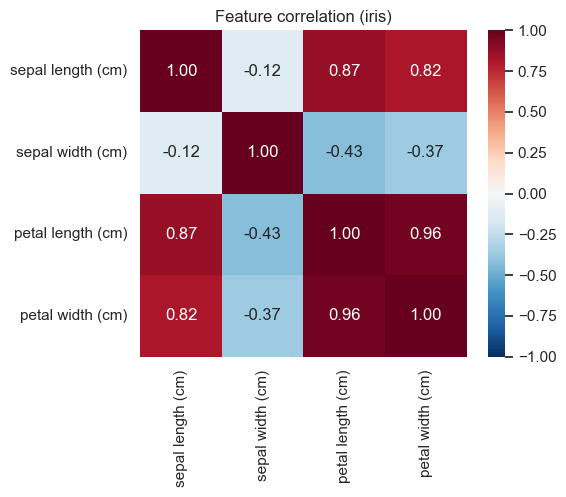

In [7]:
# Correlation heat-map of the four features (PCA thrives on correlation)
corr = pd.DataFrame(X, columns=feat_names).corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Feature correlation (iris)")
plt.tight_layout()
plt.show()


**Key insight:** petal length and petal width are **strongly correlated** (≈0.96), and both correlate with sepal length. When features move together like this, they carry **redundant** information — PCA can pack most of it into just one or two components, which is exactly why a 4-D dataset will compress so well.


## 8. Fit PCA and project to 2-D

We fit PCA on the standardized data and project the 4-D flowers down to their **top 2 components** — coordinates we can actually plot.


In [8]:
pca = PCA(n_components=2).fit(X_std)
X_pca = pca.transform(X_std)

print("Original shape:", X_std.shape, " ->  reduced shape:", X_pca.shape)
print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance kept by 2 PCs:  ", round(pca.explained_variance_ratio_[:2].sum(), 3))


Original shape: (150, 4)  ->  reduced shape: (150, 2)
Explained variance ratio (PC1, PC2): [0.73  0.229]
Cumulative variance kept by 2 PCs:   0.958


**What just happened:** we compressed **4 features → 2 components**. The printed ratios show how much variance each kept component carries; their sum is the total information retained. For iris, two components typically keep **~95%+** of the variance — a huge reduction with tiny loss.


## 9. How many components? — scree & cumulative variance

The central PCA decision is **how many components to keep**. Two standard charts guide it:

- **Scree plot:** variance captured per component (look for the "elbow").
- **Cumulative explained variance:** how much total variance the top $k$ components keep (pick $k$ at a threshold like 90–95%).


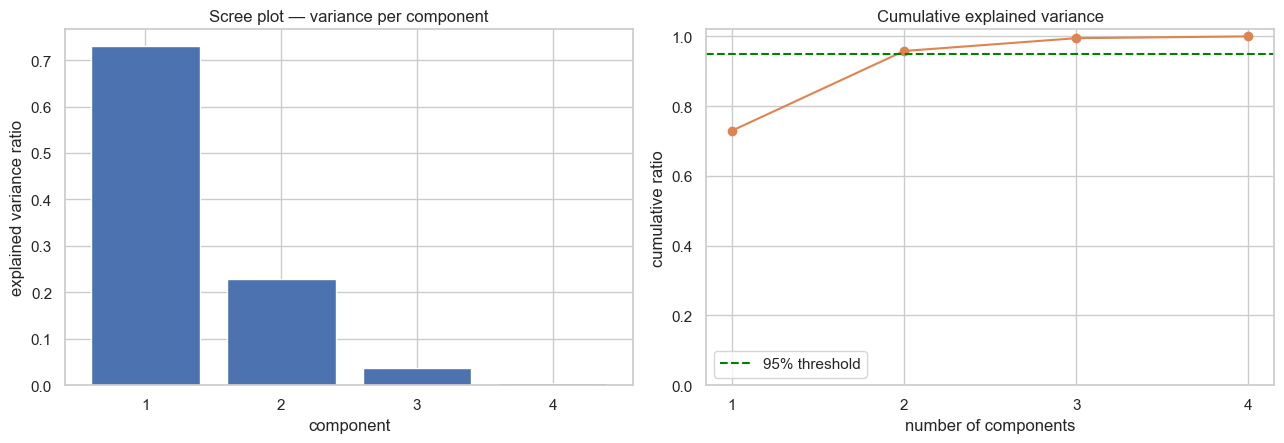

Explained variance ratio: [0.73  0.229 0.037 0.005]
Cumulative:               [0.73  0.958 0.995 1.   ]


In [9]:
pca_full = PCA(n_components=None).fit(X_std)
ratios = pca_full.explained_variance_ratio_full_
cum = np.cumsum(ratios)
comps = np.arange(1, len(ratios) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].bar(comps, ratios, color="#4c72b0")
axes[0].set_title("Scree plot — variance per component")
axes[0].set_xlabel("component"); axes[0].set_ylabel("explained variance ratio")
axes[0].set_xticks(comps)

axes[1].plot(comps, cum, "o-", color="#dd8452")
axes[1].axhline(0.95, color="green", ls="--", label="95% threshold")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("number of components"); axes[1].set_ylabel("cumulative ratio")
axes[1].set_xticks(comps); axes[1].set_ylim(0, 1.02); axes[1].legend()

plt.tight_layout()
plt.show()

print("Explained variance ratio:", np.round(ratios, 3))
print("Cumulative:              ", np.round(cum, 3))


**Key insight:** the scree plot drops off sharply after the first one or two components (the "elbow") — most of the story lives in PC1–PC2. The cumulative curve crosses **95%** at just **2 components**, which is exactly why we can plot iris in 2-D with almost no loss. On a dataset with hundreds of features, this same chart might reveal that (say) 20 components suffice — a massive compression.

### Reconstruction error vs number of components
The mirror image of "variance kept" is "detail lost". We compress to $k$ components, reconstruct, and measure the error — it should fall toward zero as $k$ grows.


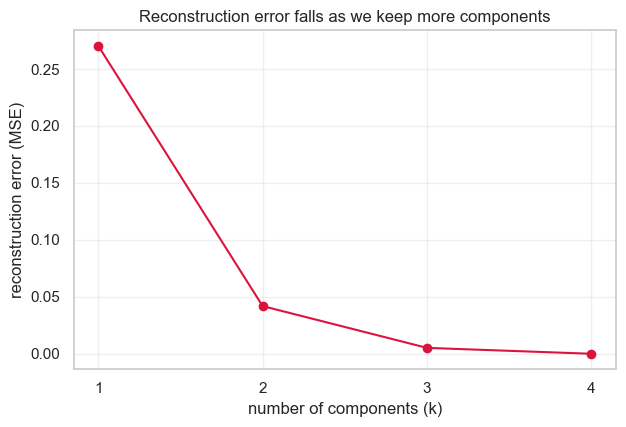

Reconstruction error by k: [0.2704 0.0419 0.0052 0.    ]


In [10]:
errors = []
ks = range(1, X_std.shape[1] + 1)
for k in ks:
    p = PCA(n_components=k).fit(X_std)
    X_rec = p.inverse_transform(p.transform(X_std))
    errors.append(reconstruction_error(X_std, X_rec))

plt.figure(figsize=(7, 4.4))
plt.plot(list(ks), errors, "o-", color="crimson")
plt.xlabel("number of components (k)")
plt.ylabel("reconstruction error (MSE)")
plt.title("Reconstruction error falls as we keep more components")
plt.xticks(list(ks)); plt.grid(True, alpha=0.3)
plt.show()

print("Reconstruction error by k:", np.round(errors, 4))


**Key insight:** with **1 component** the reconstruction is crude (high error); each added component recovers more detail until, at the full 4, the error is **~0** (perfect). The elbow here mirrors the scree elbow — both point to the same sensible $k$. This trade-off *(fewer dims vs more fidelity)* is the essence of dimensionality reduction.


## 10. Visualising the components

### The 2-D projection — structure PCA found without labels
We plot the flowers in PC1–PC2 space and colour by species **afterwards**. If PCA captured the real structure, the species should separate — even though PCA never used the labels.


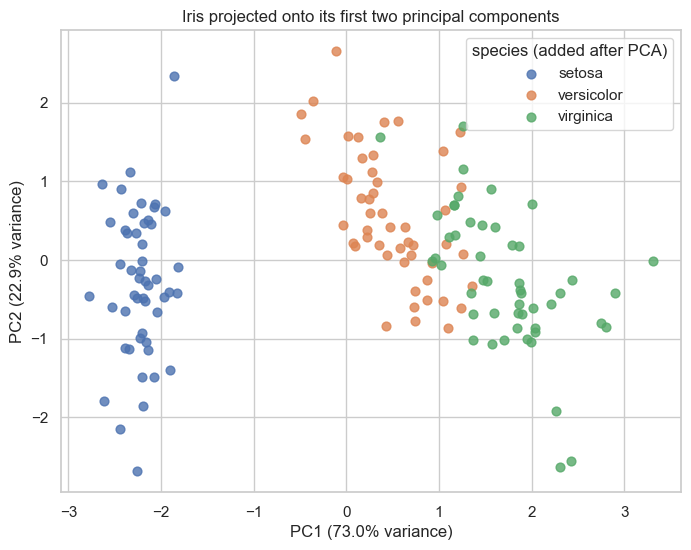

In [11]:
plt.figure(figsize=(8, 6))
for t, name in enumerate(class_names):
    m = y == t
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=40, alpha=0.8, label=name)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Iris projected onto its first two principal components")
plt.legend(title="species (added after PCA)")
plt.show()


**Key insight:** the three species fall into **clear clusters** along PC1 — yet PCA was **never told** the species. It found the directions of greatest variation, and those directions *happen* to line up with the biological differences. This "unsupervised structure discovery" is why PCA is a first move for exploring any new high-dimensional dataset.

### Component loadings — what each PC *means*
A principal component is a **weighted mix** of the original features. The weights (**loadings**) tell you what each PC represents. We show them as a grouped bar chart.


In [12]:
# Loadings: how each original feature contributes to PC1 and PC2 (Plotly)
import plotly.graph_objects as go

load = pd.DataFrame(pca.components_.T, index=feat_names, columns=["PC1", "PC2"])

fig = go.Figure()
fig.add_bar(x=load.index, y=load["PC1"], name="PC1", marker_color="#4c72b0")
fig.add_bar(x=load.index, y=load["PC2"], name="PC2", marker_color="#dd8452")
fig.update_layout(
    title=dict(text="Component loadings — how features build PC1 & PC2", x=0.5, xanchor="center"),
    xaxis_title="original feature", yaxis_title="loading (weight in the component)",
    barmode="group", template="plotly_white", width=820, height=460,
    legend=dict(x=0.98, y=0.98, xanchor="right", yanchor="top"),
)
fig.add_hline(y=0, line_color="gray")
fig.show()

display(load.round(3))


,PC1,PC2
sepal length (cm),0.521,-0.377
sepal width (cm),-0.269,-0.923
petal length (cm),0.580,-0.024
petal width (cm),0.565,-0.067


**Key insight:** **PC1** loads strongly and with the *same sign* on **petal length, petal width, and sepal length** — it's an overall "flower size / petal prominence" axis, which is what separates the species. **PC2** is dominated by **sepal width**, capturing a mostly-independent second pattern. Reading loadings turns abstract components into **interpretable factors** — the DR equivalent of feature importance.

### Principal axes drawn on the data
On two standardized features we can literally draw the principal directions, scaled by the standard deviation they capture.


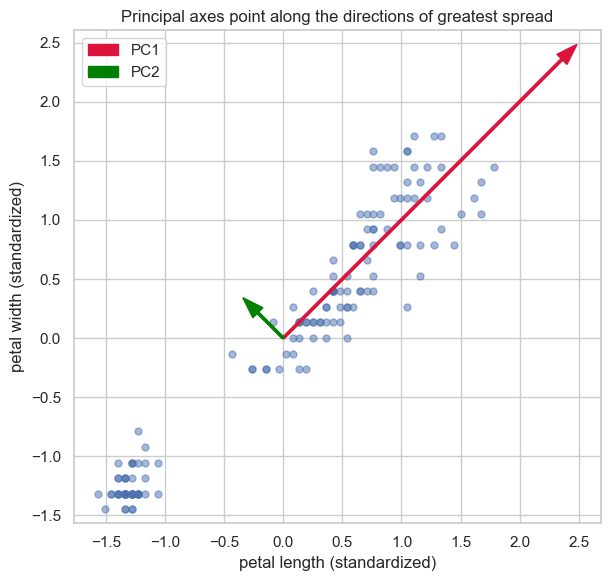

In [13]:
# Draw PC arrows on two standardized features (petal length vs petal width)
pair = [feat_names.index("petal length (cm)"), feat_names.index("petal width (cm)")]
Xp = X_std[:, pair]
p2 = PCA(n_components=2).fit(Xp)

plt.figure(figsize=(6.8, 6.4))
plt.scatter(Xp[:, 0], Xp[:, 1], s=25, alpha=0.5, color="#4c72b0")
origin = p2.mean_
for i, color in enumerate(["crimson", "green"]):
    vec = p2.components_[i] * np.sqrt(p2.explained_variance_[i]) * 2.5
    plt.arrow(origin[0], origin[1], vec[0], vec[1], color=color, width=0.02,
              head_width=0.12, length_includes_head=True, label=f"PC{i+1}")
plt.xlabel("petal length (standardized)"); plt.ylabel("petal width (standardized)")
plt.title("Principal axes point along the directions of greatest spread")
plt.legend(); plt.axis("equal")
plt.show()


**Key insight:** the **red PC1 arrow** points straight along the cloud's long axis (maximum spread); the **green PC2 arrow** is perpendicular and much shorter (little variance left). Their lengths are proportional to the variance each captures. This is the 2-D picture of what PCA does in *any* number of dimensions.


## 11. Interactive extras — rotate the principal plane, explore the trade-off

PCA isn't trained by iteration (it's one SVD), so instead of a "learning" animation we give you two **interactive** views to build geometric intuition.

> **Why no 3-D loss surface here?** PCA doesn't do gradient descent — it solves the variance problem in closed form with the SVD. The illuminating interactions for PCA are **seeing the principal plane in 3-D** and **trading components against reconstruction quality**.

#### 1. The principal plane in 3-D — rotate it
Using three standardized iris features, PCA finds the **2-D plane** that best captures the cloud. Rotate the scene with your mouse: the shaded plane is spanned by PC1 and PC2, and the points hug it — that plane is where the data "really lives".


In [14]:
# 3-D scatter + the principal plane spanned by PC1 & PC2 (rotate)
import plotly.graph_objects as go

three = [0, 2, 3]                       # sepal length, petal length, petal width (standardized)
X3 = X_std[:, three]
p3 = PCA(n_components=2).fit(X3)

# Build the plane: mean + s*PC1 + t*PC2 over a grid
span = np.linspace(-3, 3, 12)
S, T = np.meshgrid(span, span)
plane = (p3.mean_[None, None, :]
         + S[..., None] * p3.components_[0][None, None, :]
         + T[..., None] * p3.components_[1][None, None, :])
PX, PY, PZ = plane[..., 0], plane[..., 1], plane[..., 2]

names3 = [feat_names[i] for i in three]
fig = go.Figure()
fig.add_surface(x=PX, y=PY, z=PZ, opacity=0.35, showscale=False, colorscale="Greys")
for t, name in enumerate(class_names):
    m = y == t
    fig.add_scatter3d(x=X3[m, 0], y=X3[m, 1], z=X3[m, 2], mode="markers",
                      marker=dict(size=4), name=name)
fig.update_layout(
    title=dict(text="The principal plane (PC1 x PC2) through a 3-D cloud", x=0.5, xanchor="center"),
    scene=dict(xaxis_title=names3[0], yaxis_title=names3[1], zaxis_title=names3[2]),
    template="plotly_white", width=780, height=640,
)
fig.show()


**What to notice:** the semi-transparent **plane** is the best flat "sheet" through the 3-D cloud — projecting onto it (dropping to 2-D) loses very little because the points barely leave it. Rotate until you look **edge-on**: you'll see how thin the cloud is in the discarded third direction. That thinness is the variance PCA safely throws away.

#### 2. Components vs reconstruction — drag the slider
Drag `k` (or press ▶) to watch **cumulative variance kept** rise and **reconstruction error** fall. Few components = strong compression but blurrier reconstruction; more components = higher fidelity.


In [15]:
# Interactive: cumulative variance & reconstruction error vs k (play + slider)
import plotly.graph_objects as go

ks = list(range(1, X_std.shape[1] + 1))
cumk = [float(np.sum(pca_full.explained_variance_ratio_full_[:k])) for k in ks]
errk = []
for k in ks:
    p = PCA(n_components=k).fit(X_std)
    errk.append(reconstruction_error(X_std, p.inverse_transform(p.transform(X_std))))

base = [go.Scatter(x=ks, y=cumk, mode="lines+markers", name="cumulative variance kept",
                   line=dict(color="#2a9d8f")),
        go.Scatter(x=ks, y=errk, mode="lines+markers", name="reconstruction error (MSE)",
                   line=dict(color="crimson"), yaxis="y2")]

frames = [go.Frame(data=base + [go.Scatter(x=[k, k], y=[0, 1], mode="lines",
                                           line=dict(color="green", dash="dash"),
                                           showlegend=False)], name=str(k)) for k in ks]
fig_k = go.Figure(data=base + [go.Scatter(x=[ks[0], ks[0]], y=[0, 1], mode="lines",
                                          line=dict(color="green", dash="dash"), showlegend=False)],
                  frames=frames)
fig_k.update_layout(
    title=dict(text="Keep more components -> more variance, less error", x=0.5, xanchor="center"),
    xaxis_title="number of components (k)",
    yaxis=dict(title="cumulative variance", range=[0, 1.02]),
    yaxis2=dict(title="reconstruction error", overlaying="y", side="right", range=[0, max(errk) * 1.1]),
    template="plotly_white", width=800, height=480,
    legend=dict(x=0.5, y=1.15, xanchor="center", orientation="h"),
    updatemenus=[dict(type="buttons", x=0.0, y=1.28, showactive=False,
        buttons=[dict(label="Sweep k", method="animate",
                      args=[None, dict(frame=dict(duration=600, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, currentvalue=dict(prefix="k = "), x=0.1, len=0.8,
        steps=[dict(method="animate", label=str(k),
                    args=[[str(k)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for k in ks])],
)
fig_k.show()


**What to notice:** at **k=1** the teal line shows only part of the variance is kept and the red reconstruction error is **high** (poor compression). As you drag `k` up, variance kept climbs toward 100% and the error **collapses to ~0**. The best `k` is where the teal curve has nearly flattened (diminishing returns) — small `k`, big savings, tiny loss.

**More creative ideas you could add** (each just a few lines):
- a **biplot** overlaying loading arrows on the 2-D score plot;
- a **whitening** toggle (divide scores by singular values) and see the cloud become spherical;
- a **denoising** demo: add noise, keep top-k components, and watch it clean up;
- an **eigen-face / eigen-digit** grid showing what each component looks like.

> **Note for GitHub:** these Plotly interactives render in VS Code/Jupyter but **not** in GitHub's static `.ipynb` preview. Re-run the notebook locally (or export static images) to see them.


## 12. Bonus example — image compression on handwritten digits

The real magic of PCA is visible on **images**. scikit-learn's **digits** dataset is **1797** handwritten digits, each an **8×8 = 64-pixel** image. We'll treat each image as a 64-dimensional vector, compress it to a handful of components, and **reconstruct** it — watching the digit reappear from just a few numbers.


In [16]:
digits = load_digits()
Xd = digits.data                  # 1797 x 64
yd = digits.target                # 0..9 (for reference only)
print("Digits data shape:", Xd.shape, " (each row is an 8x8 image)")

# Fit PCA on all 64 dimensions (mean-centering handled inside)
pca_d = PCA(n_components=None).fit(Xd)
cum_d = np.cumsum(pca_d.explained_variance_ratio_full_)
for k in (5, 10, 20, 30, 40):
    print(f"{k:2d} components keep {cum_d[k-1]*100:5.1f}% of the variance")


Digits data shape: (1797, 64)  (each row is an 8x8 image)
 5 components keep  54.5% of the variance
10 components keep  73.8% of the variance
20 components keep  89.4% of the variance
30 components keep  95.9% of the variance
40 components keep  98.8% of the variance


**What just happened:** we fit PCA on the 64 pixel-dimensions. The printout shows the compression power: a **fraction** of the 64 components already captures most of the variance — so we can store/transmit each digit with far fewer numbers than 64 and still rebuild it.


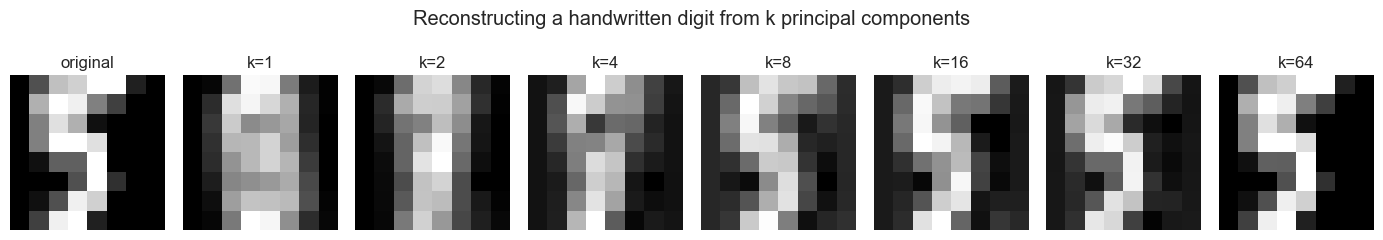

In [17]:
# Reconstruct one digit from increasing numbers of components
sample = Xd[15]                    # a single 8x8 digit (flattened)
ks = [1, 2, 4, 8, 16, 32, 64]

fig, axes = plt.subplots(1, len(ks) + 1, figsize=(14, 2.6))
axes[0].imshow(sample.reshape(8, 8), cmap="gray")
axes[0].set_title("original"); axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    p = PCA(n_components=k).fit(Xd)
    rec = p.inverse_transform(p.transform(sample.reshape(1, -1)))
    ax.imshow(rec.reshape(8, 8), cmap="gray")
    ax.set_title(f"k={k}"); ax.axis("off")
plt.suptitle("Reconstructing a handwritten digit from k principal components")
plt.tight_layout()
plt.show()


**Key insight:** with **k=1** the reconstruction is a vague blob (the "average digit" nudged one direction); by **k=8–16** the digit is clearly legible; by **k=32** it's nearly indistinguishable from the 64-pixel original. We captured almost all the visual information with **half the numbers or fewer** — that is lossy compression, and the same idea powers image/video codecs and denoising.


In [18]:
# Animate the same digit sharpening as k grows (inline video)
from matplotlib import animation
from IPython.display import HTML

k_frames = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64]
recs = []
for k in k_frames:
    p = PCA(n_components=k).fit(Xd)
    recs.append(p.inverse_transform(p.transform(sample.reshape(1, -1))).reshape(8, 8))

fig, ax = plt.subplots(figsize=(4, 4))
def draw(i):
    ax.clear()
    ax.imshow(recs[i], cmap="gray")
    ax.set_title(f"reconstructed from k = {k_frames[i]} components")
    ax.axis("off")
digit_anim = animation.FuncAnimation(fig, draw, frames=len(k_frames), interval=500)
plt.close(fig)
HTML(digit_anim.to_jshtml())


**What to notice:** press ▶ and watch the digit **emerge from fog**: each added component contributes another layer of detail, exactly in order of importance. The first few components do the heavy lifting; the last dozens only sharpen fine strokes. This visceral demo is the best way to *feel* what "explained variance" means.


## 13. Key takeaways

- PCA finds **orthogonal directions of maximum variance** (principal components) and ranks them.
- Compute it by **centering** the data and taking the **SVD** (stable) — each singular value squared is the variance of a component.
- The **explained variance ratio** and a **scree plot** tell you how many components to keep; **reconstruction error** measures what's lost.
- **Standardize first** — PCA is scale-sensitive (the opposite of decision trees).
- Projecting to the top components gives **2-D visualisations**, **compression**, and **denoising**; **loadings** make the components interpretable.
- It's **unsupervised** — it found the iris species structure without ever seeing labels — but it's **linear**, so curved manifolds may need non-linear methods (t-SNE, UMAP, kernel PCA).


## 14. Common mistakes and troubleshooting

| Problem | Cause | Fix |
|--------|-------|-----|
| One feature dominates every PC | Features on very different scales | **Standardize** before PCA |
| Components look meaningless | Forgot to **center** the data | Always subtract the mean (our `fit` does) |
| Complex-valued components | `eig` on a covariance matrix | Use the **SVD** (as here) or `eigh` |
| Too much information lost | Kept too **few** components | Raise `k` using the cumulative-variance curve |
| PCA "doesn't separate classes" | Structure is **non-linear** | Try kernel PCA, t-SNE, or UMAP |
| Leakage in a pipeline | Fit PCA on all data before splitting | **Fit on train only**, transform test |
| Sign of a component flipped | SVD sign is arbitrary | Harmless — signs carry no meaning |


## 15. Exercises

1. **Choose k.** On digits, find the smallest `k` that keeps **90%** of the variance. How much compression is that?
2. **Standardize or not.** Run iris PCA **without** standardizing. How do the loadings and 2-D plot change?
3. **Denoising.** Add Gaussian noise to a few digits, keep the top 20 components, and compare before/after.
4. **Eigen-digits.** Reshape each of `components_[:10]` to 8×8 and plot them — what patterns do they capture?
5. **Reconstruction budget.** Plot reconstruction error vs `k` for digits; where is the elbow?
6. **Compare.** Fit scikit-learn's `PCA` on both datasets and compare `explained_variance_ratio_` and the projection.
7. **Beyond linear.** Project iris with `sklearn`'s t-SNE and compare the 2-D map to PCA's.


## 16. Next steps and improvements

- **Compare with scikit-learn's `PCA`** to sanity-check components and variance ratios.
- **Use PCA as preprocessing:** reduce dimensions before a classifier to cut noise and speed training.
- **Try `TruncatedSVD`** for sparse data (e.g. text) where centering is impractical.
- **Go non-linear:** kernel PCA, t-SNE, or UMAP capture curved structure PCA can't.
- **Whitening & ZCA** for decorrelated, unit-variance features feeding downstream models.

---
*Built from the `pca.py` "ML from scratch" implementation. The center-then-eigendecompose idea is preserved, but computed via the **SVD** for numerical stability; `explained_variance_(ratio_)`, `inverse_transform`, `fit_transform`, type hints/docstrings, the tutorial structure, EDA, scree/reconstruction diagnostics, loadings, the interactive 3-D principal plane, and the digits image-compression walkthrough were added for self-study.*
